In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from os.path import join
import sys
sys.path.append(join(".", ".."))
from utils import *

In [33]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
})

separable problem

In [77]:

# pauli_trotter_steps = np.zeros((len(dimensions), len(error_tols)))

# for i in range(5):

#     data_pauli = np.load(f"../resource_analysis_data/fig2_separable_pauli_data_{i}.npz")

#     # Pauli basis
#     dimensions=data_pauli["dimensions"]
#     error_tols=data_pauli["error_tols"]
#     pauli_trotter_steps += data_pauli["pauli_basis_trotter_steps"]
#     pauli_single_qubit_gates = data_pauli["pauli_basis_single_qubit_gates"]
#     pauli_two_qubit_gates = data_pauli["pauli_basis_two_qubit_gates"]
#     pauli_basis_circ_depth = data_pauli["pauli_basis_circ_depth"]

# np.savez(join("../resource_analysis_data", "fig2_separable_pauli_data.npz"),
#         dimensions=dimensions,
#         error_tols=error_tols,
#         pauli_basis_trotter_steps=pauli_trotter_steps,
#         pauli_basis_single_qubit_gates=pauli_single_qubit_gates,
#         pauli_basis_two_qubit_gates=pauli_two_qubit_gates,
#         pauli_basis_circ_depth=pauli_basis_circ_depth)

In [78]:
data_one_hot = np.load("../resource_analysis_data/fig2_separable_one_hot_data.npz")
data_bell = np.load("../resource_analysis_data/fig2_separable_bell_data.npz")
data_pauli = np.load(f"../resource_analysis_data/fig2_separable_pauli_data.npz")

dimensions = data_one_hot["dimensions"]
error_tols = data_one_hot["error_tols"]

# Bell basis
bell_basis_trotter_steps = data_bell["bell_basis_trotter_steps"]
bell_basis_single_qubit_gates = data_bell["bell_basis_single_qubit_gates"]
bell_basis_two_qubit_gates = data_bell["bell_basis_two_qubit_gates"]
bell_basis_circ_depth_per_trotter_step = data_bell["bell_basis_circ_depth"]
bell_basis_gate_count = bell_basis_trotter_steps * (np.outer(dimensions, np.ones_like(error_tols)) * (bell_basis_single_qubit_gates + bell_basis_two_qubit_gates))
bell_basis_overall_circ_depth = bell_basis_trotter_steps * (np.outer(dimensions, np.ones_like(error_tols)) * bell_basis_circ_depth_per_trotter_step)# * bell_basis_circ_depth#(np.outer(dimensions, np.ones_like(error_tols)) * (bell_basis_single_qubit_gates + bell_basis_two_qubit_gates))

# One-hot
one_hot_trotter_steps = data_one_hot["one_hot_trotter_steps"]
one_hot_single_qubit_gates = data_one_hot["one_hot_single_qubit_gates"]
one_hot_two_qubit_gates = data_one_hot["one_hot_two_qubit_gates"]
one_hot_circ_depth_per_trotter_step = data_one_hot["one_hot_circ_depth"]
one_hot_gate_count = one_hot_trotter_steps * (np.outer(dimensions, np.ones_like(error_tols)) * (one_hot_single_qubit_gates + one_hot_two_qubit_gates))
one_hot_overall_circ_depth = one_hot_trotter_steps * (np.outer(dimensions, np.ones_like(error_tols)) * one_hot_circ_depth_per_trotter_step)# * one_hot_circ_depth#(np.outer(dimensions, np.ones_like(error_tols)) * (one_hot_single_qubit_gates + one_hot_two_qubit_gates))

# Pauli basis
pauli_trotter_steps = data_pauli["pauli_basis_trotter_steps"]
pauli_single_qubit_gates = data_pauli["pauli_basis_single_qubit_gates"]
pauli_two_qubit_gates = data_pauli["pauli_basis_two_qubit_gates"]
pauli_circ_depth_per_trotter_step = data_pauli["pauli_basis_circ_depth"]
pauli_gate_count = pauli_trotter_steps * (np.outer(dimensions, np.ones_like(error_tols)) * (pauli_single_qubit_gates + pauli_two_qubit_gates))
pauli_circ_overall_depth = pauli_trotter_steps * (np.outer(dimensions, np.ones_like(error_tols)) * pauli_circ_depth_per_trotter_step)


In [79]:
def log_tick_formatter(val, pos=None):
    return f"$10^{{{int(val)}}}$"  # remove int() if you don't use MaxNLocator
    # return f"{10**val:.2e}"      # e-Notation

<Figure size 640x480 with 0 Axes>

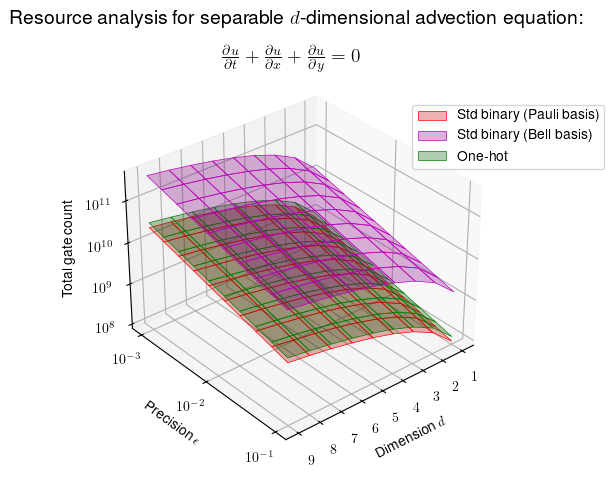

In [80]:

plt.clf()

ax = plt.figure(figsize=(12, 5)).add_subplot(projection='3d')

X, Y = np.meshgrid(dimensions, np.log10(error_tols), indexing='ij')
# Plot the 3D surface
ax.plot_surface(X, Y, np.log10(pauli_gate_count), color='red', edgecolor='red', lw=0.5, rstride=1, cstride=1,
                alpha=0.3, label="Std binary (Pauli basis)")
ax.plot_surface(X, Y, np.log10(bell_basis_gate_count), color="m", edgecolor='m', lw=0.5, rstride=1, cstride=1,
                alpha=0.3, label="Std binary (Bell basis)")
ax.plot_surface(X, Y, np.log10(one_hot_gate_count), color="green", edgecolor='green', lw=0.5, rstride=1, cstride=1,
                alpha=0.3, label="One-hot")
ax.view_init(elev=32, azim=50, roll=0)

ax.zaxis.set_rotate_label(False)
ax.set_xlabel(rf"Dimension $d$")
ax.set_ylabel(rf"Precision $\epsilon$")
ax.set_zlabel("Total gate count", rotation=90)

ax.zaxis.set_major_formatter(mticker.FuncFormatter(log_tick_formatter))
ax.zaxis.set_major_locator(mticker.MaxNLocator(integer=True))


ax.yaxis.set_major_formatter(mticker.FuncFormatter(log_tick_formatter))
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
# ax.zaxis._set_scale('log')
ax.legend(loc=(0.8,0.75))
# ax.text2D(x=0.1, y=0.096, s=r"$\frac{\partial u}{\partial t} + \frac{\partial u}{\partial x_1} + \frac{\partial u}{\partial x_2} = 0$")
plt.title(r"Resource analysis for separable $d$-dimensional advection equation:", y=1.2, size=14)
plt.figtext(x=0.45, y=0.9, s=r"$\frac{\partial u}{\partial t} + \frac{\partial u}{\partial x} + \frac{\partial u}{\partial y} = 0$", size=14)
# plt.savefig(join("..", "..", "figures", "Fig_2_separable.pdf"), bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

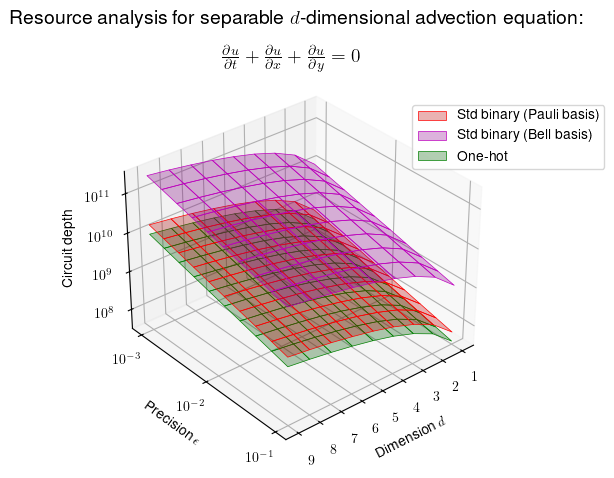

In [81]:

plt.clf()

ax = plt.figure(figsize=(12, 5)).add_subplot(projection='3d')

X, Y = np.meshgrid(dimensions, np.log10(error_tols), indexing='ij')
# Plot the 3D surface
ax.plot_surface(X, Y, np.log10(pauli_circ_overall_depth), color='red', edgecolor='red', lw=0.5, rstride=1, cstride=1,
                alpha=0.3, label="Std binary (Pauli basis)")
ax.plot_surface(X, Y, np.log10(bell_basis_overall_circ_depth), color="m", edgecolor='m', lw=0.5, rstride=1, cstride=1,
                alpha=0.3, label="Std binary (Bell basis)")
ax.plot_surface(X, Y, np.log10(one_hot_overall_circ_depth), color="green", edgecolor='green', lw=0.5, rstride=1, cstride=1,
                alpha=0.3, label="One-hot")
ax.view_init(elev=32, azim=50, roll=0)

ax.zaxis.set_rotate_label(False)
ax.set_xlabel(rf"Dimension $d$")
ax.set_ylabel(rf"Precision $\epsilon$")
ax.set_zlabel("Circuit depth", rotation=90)

ax.zaxis.set_major_formatter(mticker.FuncFormatter(log_tick_formatter))
ax.zaxis.set_major_locator(mticker.MaxNLocator(integer=True))


ax.yaxis.set_major_formatter(mticker.FuncFormatter(log_tick_formatter))
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
# ax.zaxis._set_scale('log')
ax.legend(loc=(0.8,0.75))
# ax.text2D(x=0.1, y=0.096, s=r"$\frac{\partial u}{\partial t} + \frac{\partial u}{\partial x_1} + \frac{\partial u}{\partial x_2} = 0$")
plt.title(r"Resource analysis for separable $d$-dimensional advection equation:", y=1.2, size=14)
plt.figtext(x=0.45, y=0.9, s=r"$\frac{\partial u}{\partial t} + \frac{\partial u}{\partial x} + \frac{\partial u}{\partial y} = 0$", size=14)
# plt.savefig(join("..", "..", "figures", "Fig_2_separable.pdf"), bbox_inches='tight')
plt.show()

nonseparable problem

In [82]:
trotter_method = "first_order"
data = np.load(f"../resource_analysis_data/fig2_nonseparable_data_{trotter_method}.npz")
error_tols = data["error_tols"]

pauli_basis_trotter_steps = data["pauli_basis_trotter_steps"]
pauli_basis_single_qubit_gates = data["pauli_basis_single_qubit_gates"]
pauli_basis_two_qubit_gates = data["pauli_basis_two_qubit_gates"]
pauli_basis_circ_depth_per_trotter_step = data["pauli_basis_circ_depth"]
pauli_basis_overall_circ_depth = pauli_basis_trotter_steps * pauli_basis_circ_depth_per_trotter_step

one_hot_trotter_steps = data["one_hot_trotter_steps"]
one_hot_single_qubit_gates = data["one_hot_single_qubit_gates"]
one_hot_two_qubit_gates = data["one_hot_two_qubit_gates"]
one_hot_circ_depth_per_trotter_step = data["one_hot_circ_depth"]
one_hot_overall_circ_depth = one_hot_trotter_steps * one_hot_circ_depth_per_trotter_step


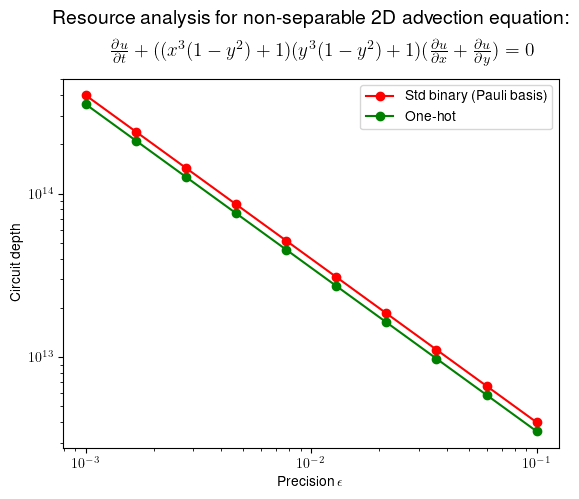

In [83]:
plt.plot(error_tols, pauli_basis_overall_circ_depth, '-o', color="red", label="Std binary (Pauli basis)")
plt.plot(error_tols, one_hot_overall_circ_depth, '-o', color="green", label="One-hot")
plt.title(r"Resource analysis for non-separable 2D advection equation:", y=1.125, size=14)
plt.figtext(x=0.2, y=0.925, s=r"$\frac{\partial u}{\partial t}+((x^3(1-y^2)+1)(y^3(1-y^2)+1)(\frac{\partial u}{\partial x} + \frac{\partial u}{\partial y}) = 0$", size=14)
plt.ylabel("Circuit depth")
plt.xlabel(rf"Precision $\epsilon$")
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.savefig(join("..", "..", "figures", "Fig_2_nonseparable.pdf"), bbox_inches='tight')
plt.show()

nonlinear problem

In [15]:
trotter_method = "first_order"
data = np.load(f"../resource_analysis_data/nonlinear_data_{trotter_method}.npz")
error_tols = data["error_tols"]

pauli_basis_trotter_steps = data["pauli_basis_trotter_steps"]
pauli_basis_single_qubit_gates = data["pauli_basis_single_qubit_gates"]
pauli_basis_two_qubit_gates = data["pauli_basis_two_qubit_gates"]
pauli_basis_circ_depth_per_trotter_step = data["pauli_basis_circ_depth"]
pauli_basis_overall_circ_depth = pauli_basis_trotter_steps * pauli_basis_circ_depth_per_trotter_step

one_hot_trotter_steps = data["one_hot_trotter_steps"]
one_hot_single_qubit_gates = data["one_hot_single_qubit_gates"]
one_hot_two_qubit_gates = data["one_hot_two_qubit_gates"]
one_hot_circ_depth_per_trotter_step = data["one_hot_circ_depth"]
one_hot_overall_circ_depth = one_hot_trotter_steps * one_hot_circ_depth_per_trotter_step


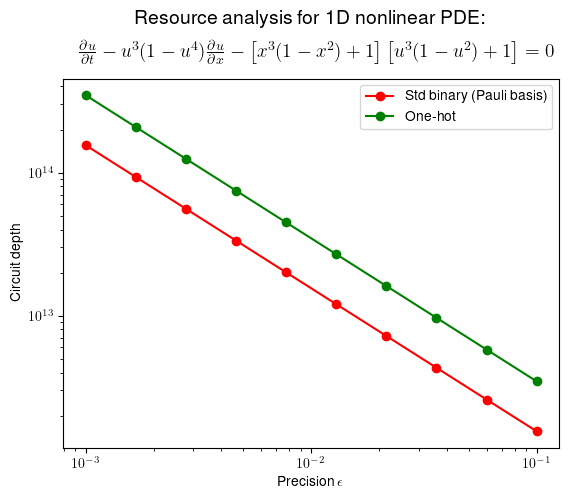

In [16]:
plt.plot(error_tols, pauli_basis_overall_circ_depth, '-o', color="red", label="Std binary (Pauli basis)")
plt.plot(error_tols, one_hot_overall_circ_depth, '-o', color="green", label="One-hot")
plt.title(r"Resource analysis for 1D nonlinear PDE:", y=1.125, size=14)
plt.figtext(x=0.15, y=0.925, s=r"$\frac{\partial u}{\partial t} - u^3 (1-u^4)\frac{\partial u}{\partial x} - \left[x^3(1-x^2)+1\right]\left[u^3(1-u^2)+1\right]=0$", size=14)
plt.ylabel("Circuit depth")
plt.xlabel(rf"Precision $\epsilon$")
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.savefig(join("..", "..", "figures", "nonlinear_resource_analysis.pdf"), bbox_inches='tight')
plt.show()